# Linear Regression Example

Linear regression implementation with TensorFlow v2 library.

This example is using a low-level approach to better understand all mechanics behind the training process.

In [1]:
!pip install -U protobuf==3.8.0

Requirement already up-to-date: protobuf==3.8.0 in /usr/local/lib/python3.6/dist-packages (3.8.0)


In [2]:
%tensorflow_version 2.x

In [3]:
from __future__ import absolute_import, division, print_function

In [4]:
import tensorflow as tf
import numpy as np
rng = np.random

In [5]:
# Parameters.
learning_rate = 0.01
training_steps = 1000
display_step = 50

In [6]:
# Training Data.
X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])
Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])
n_samples = X.shape[0]

In [7]:
# Weight and Bias, initialized randomly.
W = tf.Variable(rng.randn(), name="weight")
b = tf.Variable(rng.randn(), name="bias")

# Linear regression (Wx + b).
def linear_regression(x):
    return W * x + b

# Mean square error.
def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred-y_true, 2)) / (2 * n_samples)

# Stochastic Gradient Descent Optimizer.
optimizer = tf.optimizers.SGD(learning_rate)

In [8]:
# Optimization process. 
def run_optimization():
    # Wrap computation inside a GradientTape for automatic differentiation.
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square(pred, Y)

    # Compute gradients.
    gradients = g.gradient(loss, [W, b])
    
    # Update W and b following gradients.
    optimizer.apply_gradients(zip(gradients, [W, b]))

In [9]:
# Run training for the given number of steps.
for step in range(1, training_steps + 1):
    # Run the optimization to update W and b values.
    run_optimization()
    
    if step % display_step == 0:
        pred = linear_regression(X)
        loss = mean_square(pred, Y)
        print("step: %i, loss: %f, W: %f, b: %f" % (step, loss, W.numpy(), b.numpy()))

step: 50, loss: 0.144333, W: 0.104444, b: 1.842322
step: 100, loss: 0.136624, W: 0.113116, b: 1.780837
step: 150, loss: 0.129796, W: 0.121278, b: 1.722974
step: 200, loss: 0.123750, W: 0.128959, b: 1.668520
step: 250, loss: 0.118395, W: 0.136187, b: 1.617275
step: 300, loss: 0.113652, W: 0.142989, b: 1.569050
step: 350, loss: 0.109452, W: 0.149391, b: 1.523666
step: 400, loss: 0.105733, W: 0.155415, b: 1.480956
step: 450, loss: 0.102438, W: 0.161085, b: 1.440763
step: 500, loss: 0.099521, W: 0.166420, b: 1.402938
step: 550, loss: 0.096937, W: 0.171441, b: 1.367342
step: 600, loss: 0.094649, W: 0.176166, b: 1.333843
step: 650, loss: 0.092622, W: 0.180613, b: 1.302317
step: 700, loss: 0.090827, W: 0.184797, b: 1.272649
step: 750, loss: 0.089238, W: 0.188736, b: 1.244729
step: 800, loss: 0.087830, W: 0.192442, b: 1.218455
step: 850, loss: 0.086583, W: 0.195929, b: 1.193729
step: 900, loss: 0.085479, W: 0.199212, b: 1.170459
step: 950, loss: 0.084501, W: 0.202301, b: 1.148560
step: 1000, l

In [10]:
import matplotlib.pyplot as plt

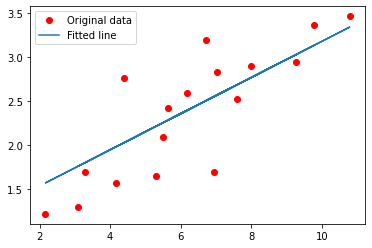

In [11]:
# Graphic display
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()